# ECG Health-State Recognition — Supervised Framework Without Fault Samples

**Paper:** A Supervised Framework for Recognition of Liquid Rocket Engine Health State  
Under Steady-State Process Without Fault Samples  

**Cross-domain validation dataset:** MIT-BIH Arrhythmia Database (PhysioNet)  

**Core idea:** Train only on normal windows. Synthesise negative samples using  
morphology sharpening + frequency perturbation. Estimate a decision threshold  
from normal-only validation scores (μ + k·σ). Evaluate on real arrhythmia windows  
labelled from PhysioNet beat annotations — not from record identity.



In [25]:
!pip install wfdb seaborn --quiet

## 1 — Imports & Reproducibility

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import random

from scipy.signal import butter, filtfilt, resample

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    f1_score,
)

import seaborn as sns
import wfdb


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2 — Visualisation Helpers

In [27]:
def plot_ecg(signal, title="ECG Signal", figsize=(15, 4)):
    plt.figure(figsize=figsize)
    plt.plot(signal)
    plt.title(title)
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def compare_signals(original, modified, title1="Original", title2="Modified"):
    plt.figure(figsize=(15, 6))
    plt.subplot(2, 1, 1)
    plt.plot(original)
    plt.title(title1)
    plt.grid(True)
    plt.subplot(2, 1, 2)
    plt.plot(modified)
    plt.title(title2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_frequency_spectrum(signal, fs=360, title="Frequency Spectrum"):
    n = len(signal)
    frequencies = np.fft.fftfreq(n, d=1 / fs)
    fft_values = np.abs(np.fft.fft(signal))
    plt.figure(figsize=(14, 4))
    plt.plot(frequencies[: n // 2], fft_values[: n // 2])
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 3 — Preprocessing

In [28]:
def bandpass_filter(
    signal, lowcut: float = 0.5, highcut: float = 40.0,
    fs: int = 360, order: int = 4, visualize: bool = False
):
    nyquist = 0.5 * fs
    b, a = butter(order, [lowcut / nyquist, highcut / nyquist], btype="band")
    filtered = filtfilt(b, a, signal)
    if visualize:
        compare_signals(signal, filtered, "Raw ECG", "Band-pass Filtered ECG")
    return filtered


def normalize_signal(signal):
    std = np.std(signal)
    if std < 1e-8:
        return signal - np.mean(signal)
    return (signal - np.mean(signal)) / std


def sliding_window(
    signal, window_size: int = 720, step: int = 360, visualize: bool = False
):
    windows = [
        signal[s : s + window_size]
        for s in range(0, len(signal) - window_size, step)
    ]
    windows = np.array(windows)
    if visualize:
        print("Total windows:", len(windows))
        for i in range(min(3, len(windows))):
            plot_ecg(windows[i], title=f"Window {i + 1}")
    return windows

## 4 — Synthetic Negative Sample Generation

Implements the paper's two core transforms:  
- **Morphology sharpening** → vibration-sharpening analogue (non-linear amplitude distortion)  
- **Frequency perturbation** → resampling-superposition analogue (time-scale shift)  

Plus `amplitude_distortion` as an additional augmentation.

> **FIX 4** — `rhythm_variation` (Gaussian noise only, mean diff ≈ 0.04 on std=1 signal)  
> is never applied alone. It is always stacked on top of a strong augmentation.  
> This prevents near-normal windows from receiving label = 1.

In [29]:
def amplitude_distortion(signal, visualize: bool = False):
    """
    Scale amplitude into a region meaningfully different from 1.0.
    Draws from [0.4, 0.7] (shrink) or [1.3, 1.8] (grow) with equal probability.
    """
    scale = (
        np.random.uniform(0.4, 0.7)
        if random.random() < 0.5
        else np.random.uniform(1.3, 1.8)
    )
    distorted = signal * scale
    if visualize:
        print(f"  amplitude_distortion  scale={scale:.3f}")
        compare_signals(signal, distorted, "Original", "Amplitude Distorted")
    return distorted


def morphology_sharpening(signal, gamma: float = 2.0, lam: float = 0.5,
                           visualize: bool = False):
    """
    Paper's vibration-sharpening analogue.
    Applies a non-linear power transform to exaggerate peaks/troughs.
    Division-by-zero guard: returns original if signal is flat.
    """
    denom = np.max(np.abs(signal) ** gamma)
    if denom < 1e-8:
        return signal.copy()
    sharpened = (
        lam * signal
        + (1 - lam) * np.sign(signal) * (np.abs(signal) ** gamma) / denom
    )
    if visualize:
        print(f"  morphology_sharpening  gamma={gamma}, lambda={lam}")
        compare_signals(signal, sharpened, "Original", "Morphology Sharpened")
    return sharpened


def frequency_perturbation(signal, visualize: bool = False):
    """
    Paper's resampling-superposition analogue.
    Stretches/compresses the signal in time by 0.8–1.2×, then restores length.
    This shifts the frequency content without changing the window size.
    """
    factor = np.random.uniform(0.8, 1.2)
    stretched = resample(resample(signal, int(len(signal) * factor)), len(signal))
    if visualize:
        print(f"  frequency_perturbation  factor={factor:.3f}")
        compare_signals(signal, stretched, "Original", "Frequency Perturbed")
        plot_frequency_spectrum(signal, title="Original Spectrum")
        plot_frequency_spectrum(stretched, title="Perturbed Spectrum")
    return stretched


def rhythm_variation(signal, noise_level: float = 0.15, visualize: bool = False):
    """
    Adds Gaussian noise.  noise_level raised to 0.15 (was 0.05).
    NEVER applied alone — always stacked after a strong augmentation.
    """
    output = signal + np.random.normal(0, noise_level, len(signal))
    if visualize:
        print(f"  rhythm_variation  noise_level={noise_level}")
        compare_signals(signal, output, "Original", "Rhythm Variation")
    return output


# ── Strong augmentations (guaranteed to produce a distinguishable anomaly) ──
_STRONG_OPS = [amplitude_distortion, morphology_sharpening, frequency_perturbation]


def generate_negative_sample(signal, visualize: bool = False):
    """
    FIX 4 — Generation strategy:
      1. Always apply one strong op (amplitude / morphology / frequency).
      2. With 50 % probability, also stack rhythm_variation on top.
      3. Optionally stack a second distinct strong op with 30 % probability.

    This guarantees every synthetic anomaly is meaningfully different
    from its normal counterpart (no near-identical label-1 samples).
    """
    output = signal.copy()

    if visualize:
        print("\nApplied augmentations:")

    # Step 1 — one strong op (always)
    strong_op = random.choice(_STRONG_OPS)
    output = strong_op(output, visualize=visualize)

    # Step 2 — optionally stack a second distinct strong op
    if random.random() < 0.30:
        remaining = [op for op in _STRONG_OPS if op is not strong_op]
        output = random.choice(remaining)(output, visualize=visualize)

    # Step 3 — optionally add rhythm_variation on top
    if random.random() < 0.50:
        output = rhythm_variation(output, visualize=visualize)

    return output

## 5 — Dataset Classes

In [30]:
class ECGDataset(Dataset):
    """
    Training / validation-monitoring dataset.
    Doubles the effective size by pairing each normal window with
    one on-the-fly synthetic anomaly → guaranteed 50 / 50 balance.

    Index layout:
      even idx  →  normal window,           label = 0
      odd  idx  →  synthetic anomaly,       label = 1
    Shuffle re-orders which even/odd indices arrive in each batch
    without breaking the pairing logic.
    """

    def __init__(self, healthy_windows: np.ndarray):
        self.windows = healthy_windows

    def __len__(self):
        return len(self.windows) * 2

    def __getitem__(self, idx: int):
        base = self.windows[idx // 2]
        if idx % 2 == 0:
            signal, label = base, 0
        else:
            signal, label = generate_negative_sample(base), 1
        return torch.tensor(signal, dtype=torch.float32).unsqueeze(0), label


class ValDataset(Dataset):
    """
    Normal-only validation dataset.
    Used EXCLUSIVELY for μ + k·σ threshold estimation after training —
    the paper's boundary-learning mechanism.
    NOT used for checkpointing (see FIX 2).
    """

    def __init__(self, normal_windows: np.ndarray):
        self.windows = normal_windows

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx: int):
        signal = torch.tensor(self.windows[idx], dtype=torch.float32).unsqueeze(0)
        return signal, 0


class TestDataset(Dataset):
    """
    FIX 1 — Test dataset with per-window labels derived from
    PhysioNet beat annotations, not from record identity.
    A window is labelled 1 only if at least one annotated
    arrhythmia beat falls within it.
    """

    def __init__(self, windows: np.ndarray, labels: np.ndarray):
        assert len(windows) == len(labels), "windows / labels length mismatch"
        self.windows = windows
        self.labels  = labels

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx: int):
        signal = torch.tensor(self.windows[idx], dtype=torch.float32).unsqueeze(0)
        return signal, int(self.labels[idx])

## 6 — FRCNN Model

Architecture: LSTM (temporal dependencies) → two CNN blocks (local morphology) →  
global average pooling → single binary logit.  
Padding is computed dynamically (`kernel_size // 2`) so the architecture is  
safe to any odd kernel size without breaking `fc` input dimensions.

In [31]:
class ECGFRCNN(nn.Module):
    """
    Fusion Recurrent–Convolutional Neural Network.

    Input  : [batch, 1, window_size]  (single-lead ECG window)
    Output : [batch]                  (single logit — use with BCEWithLogitsLoss)

    Padding = kernel_size // 2  →  same-length convolution for any odd kernel.
    Global average pooling replaces the hardcoded flatten, so fc input size
    is always 128 regardless of window_size.
    """

    def __init__(
        self,
        lstm_hidden: int = 64,
        cnn_filters_1: int = 64,
        cnn_filters_2: int = 128,
        kernel_size: int = 5,
        dropout: float = 0.3,
    ):
        super().__init__()
        pad = kernel_size // 2  # same-length convolution for any odd kernel

        self.lstm  = nn.LSTM(input_size=1, hidden_size=lstm_hidden, batch_first=True)

        self.conv1 = nn.Conv1d(lstm_hidden, cnn_filters_1, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(cnn_filters_1)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(cnn_filters_1, cnn_filters_2, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(cnn_filters_2)
        self.pool2 = nn.MaxPool1d(2)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.gap     = nn.AdaptiveAvgPool1d(1)   # global average pooling → [batch, 128, 1]
        self.fc      = nn.Linear(cnn_filters_2, 1)

    def forward(self, x):
        # x: [batch, 1, length]
        x, _ = self.lstm(x.permute(0, 2, 1))     # [batch, length, lstm_hidden]
        x = x.permute(0, 2, 1)                    # [batch, lstm_hidden, length]

        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))

        x = self.gap(x).squeeze(-1)               # [batch, 128]
        x = self.dropout(x)
        return self.fc(x).squeeze(-1)             # [batch]

## 7 — Training & Threshold Utilities

In [32]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for signals, labels in loader:
        signals = signals.to(device)
        labels  = labels.float().to(device)
        optimizer.zero_grad()
        loss = criterion(model(signals), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate_f1(model, loader, threshold: float = 0.5):
    """
    FIX 2 — Compute F1 on a mixed (normal + synthetic) loader.
    Used for model checkpointing instead of trivial normal-accuracy.
    """
    model.eval()
    y_true, y_pred = [], []
    for signals, labels in loader:
        probs = torch.sigmoid(model(signals.to(device))).cpu().numpy().reshape(-1)
        y_pred.extend((probs > threshold).astype(int).tolist())
        y_true.extend(labels.numpy().tolist())
    return f1_score(y_true, y_pred, zero_division=0)


@torch.no_grad()
def estimate_threshold(model, val_loader, k: float = 3.0) -> float:
    """
    Paper's boundary-learning mechanism.
    Runs on normal-only windows; computes threshold = μ + k·σ of sigmoid outputs.
    Clipped to [0.0, 0.95] — upper cap reduced from 0.99 to 0.95 to
    preserve sensitivity when the model is highly confident on normal data.
    """
    model.eval()
    probs = []
    for signals, _ in val_loader:
        p = torch.sigmoid(model(signals.to(device))).cpu().numpy().reshape(-1)
        probs.extend(p.tolist())
    probs = np.array(probs)
    mu, sigma = probs.mean(), probs.std()
    threshold = float(np.clip(mu + k * sigma, 0.0, 0.95))
    print(f"\nNormal val scores  μ={mu:.4f}  σ={sigma:.4f}")
    print(f"Decision threshold (μ + {k}·σ) = {threshold:.4f}\n")
    return threshold

## 8 — Training Loop

In [33]:
def run_training(
    model,
    train_loader,
    val_monitor_loader,   # ECGDataset — mixed normal + synthetic, for F1 checkpointing
    num_epochs: int = 10,
    checkpoint_path: str = "best_ecg_model.pt",
):
    """
    FIX 2 — Checkpoints on val F1 (synthetic anomalies) instead of
             normal-only accuracy, which trivially approaches 100 %.
    FIX 3 — torch.load uses map_location=device.
    FIX 5 — 'saved' boolean flag prevents false '← saved' display.
    """
    criterion     = nn.BCEWithLogitsLoss()
    optimizer     = optim.Adam(model.parameters(), lr=1e-3)
    scheduler     = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    best_val_f1   = 0.0
    train_losses  = []
    val_f1_scores = []

    print("\nStarting training ...\n")
    print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Val F1':>8}  {'LR':>8}")
    print("-" * 45)

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_f1     = evaluate_f1(model, val_monitor_loader, threshold=0.5)
        scheduler.step()

        train_losses.append(train_loss)
        val_f1_scores.append(val_f1)

        # FIX 5 — boolean flag: only True when we actually saved
        saved = False
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), checkpoint_path)
            saved = True

        lr_now = scheduler.get_last_lr()[0]
        print(
            f"  {epoch+1:02d}/{num_epochs}  "
            f"loss={train_loss:.4f}  "
            f"val_f1={val_f1:.4f}  "
            f"lr={lr_now:.5f}"
            + ("  ← saved" if saved else "")
        )

    print(f"\nBest val F1: {best_val_f1:.4f}")

    # FIX 3 — map_location so loading works on both CPU and GPU
    model.load_state_dict(
        torch.load(checkpoint_path, weights_only=True, map_location=device)
    )
    print("Best checkpoint loaded.")

    return model, train_losses, val_f1_scores

## 9 — Evaluation & Visualisation

In [34]:
def plot_training_curves(losses, val_f1_scores):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(losses, marker="o")
    plt.title("Training Loss (BCE)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(val_f1_scores, marker="o", color="darkorange")
    plt.title("Val F1 — Normal + Synthetic (checkpoint metric)")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=["Normal", "Anomaly"],
        yticklabels=["Normal", "Anomaly"],
    )
    plt.title("Confusion Matrix — Real Arrhythmia Test Set")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_probs):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Real Arrhythmia Test Set")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def full_evaluation(model, loader, threshold: float):
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    for signals, labels in loader:
        probs = torch.sigmoid(model(signals.to(device))).cpu().numpy().reshape(-1)
        y_probs.extend(probs.tolist())
        y_pred.extend((probs > threshold).astype(int).tolist())
        y_true.extend(
            labels.numpy().tolist() if isinstance(labels, torch.Tensor)
            else list(labels)
        )
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))
    plot_confusion_matrix(y_true, y_pred)
    plot_roc_curve(y_true, y_probs)


@torch.no_grad()
def visualize_predictions(model, dataset, threshold: float, num_samples: int = 6):
    model.eval()
    for i in range(min(num_samples, len(dataset))):
        signal, label = dataset[i]
        prob = torch.sigmoid(model(signal.unsqueeze(0).to(device))).item()
        pred = int(prob > threshold)
        plot_ecg(
            signal.squeeze().numpy(),
            title=(
                f"True: {'Anomaly' if label else 'Normal'}  |  "
                f"Pred: {'Anomaly' if pred else 'Normal'}  |  "
                f"P(anomaly)={prob:.3f}  threshold={threshold:.3f}"
            ),
        )

## 10 — Data Loading

### FIX 1 — Annotation-based window labelling

MIT-BIH beat symbols classed as **normal** (label = 0):  
`N` (normal), `L` (LBBB), `R` (RBBB), `e` (atrial escape), `j` (nodal escape)  

Everything else — PVC, fusion, paced, unclassified, etc. — is **anomalous** (label = 1).  
A window is labelled 1 if **any** annotated arrhythmia beat falls inside it.  

Record composition reference (PhysioNet):  
- Record 100 → 99.9 % normal  (training source)  
- Record 108 → 96.1 % normal beats  (labelling via annotations, not record identity)  
- Record 200 → 67.0 % normal beats  (labelling via annotations, not record identity)

In [35]:
# Beat symbols considered NORMAL — everything else is arrhythmia
_NORMAL_SYMBOLS = {"N", "L", "R", "e", "j"}


def load_record_windows(
    record_path: str,
    window_size: int = 720,
    step: int = 360,
    return_labels: bool = False,
):
    """
    Load, filter, normalise and window a wfdb record.

    If return_labels=True, also loads .atr annotations and assigns
    per-window labels based on whether an arrhythmia beat falls inside
    the window — FIX 1's core logic.
    """
    record = wfdb.rdrecord(record_path)
    sig    = bandpass_filter(record.p_signal[:, 0])
    sig    = normalize_signal(sig)
    wins   = sliding_window(sig, window_size=window_size, step=step)

    if not return_labels:
        return wins

    # Build a set of sample indices where an arrhythmia beat was annotated
    annot = wfdb.rdann(record_path, "atr")
    arrhythmia_positions = set(
        int(s)
        for s, sym in zip(annot.sample, annot.symbol)
        if sym not in _NORMAL_SYMBOLS
    )

    labels = np.array([
        int(any(
            (start := i * step) <= pos < start + window_size
            for pos in arrhythmia_positions
        ))
        for i in range(len(wins))
    ])

    n_anom = labels.sum()
    print(
        f"  {record_path}:  {len(wins)} windows  →  "
        f"{n_anom} anomalous ({100*n_anom/len(wins):.1f} %)  "
        f"{len(wins)-n_anom} normal"
    )
    return wins, labels

Generating record list for: 100
Generating record list for: 101
Generating record list for: 103
Generating record list for: 115
Generating record list for: 117
Generating record list for: 122
Generating record list for: 123
Generating list of all files for: 100
Generating list of all files for: 101
Generating list of all files for: 103
Generating list of all files for: 115
Generating list of all files for: 117
Generating list of all files for: 122
Generating list of all files for: 123
Finished downloading files
Generating record list for: 108
Generating record list for: 200
Generating list of all files for: 108
Generating list of all files for: 200
Finished downloading files

Loading normal training records ...
  record 100: 1804 windows
  record 101: 1804 windows
  record 103: 1804 windows
  record 115: 1804 windows
  record 117: 1804 windows
  record 122: 1804 windows
  record 123: 1804 windows

Total normal windows: 12628


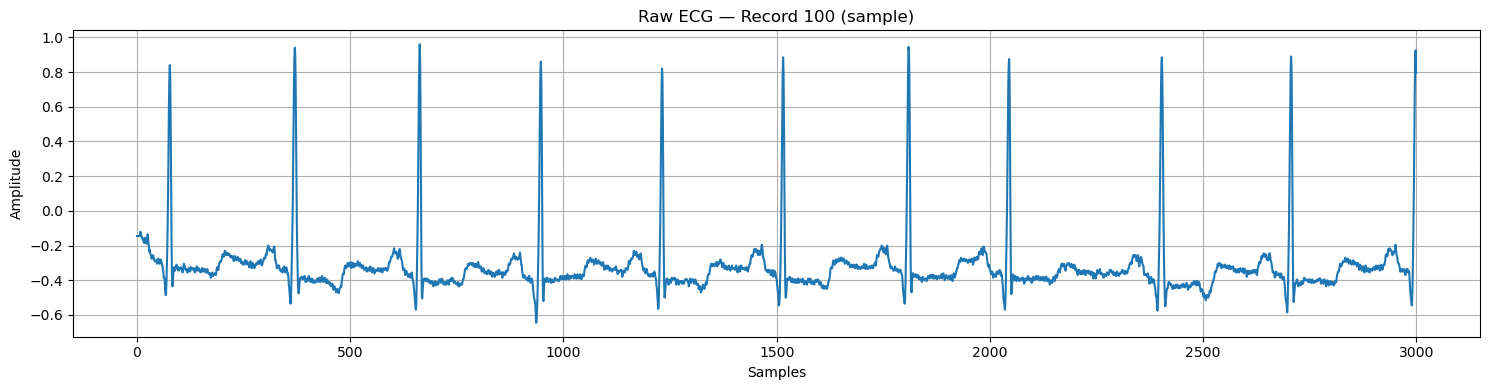

In [36]:
NORMAL_RECORDS  = ["100", "101", "103", "115", "117", "122", "123"]
ANOMALY_RECORDS = ["108", "200"]

print("Downloading normal training records ...")
wfdb.dl_database("mitdb", dl_dir="mitdb", records=NORMAL_RECORDS)

print("Downloading arrhythmia test records ...")
wfdb.dl_database("mitdb", dl_dir="mitdb", records=ANOMALY_RECORDS)

print("\nLoading normal training records ...")
all_normal_windows = []
for rec in NORMAL_RECORDS:
    wins = load_record_windows(f"mitdb/{rec}")
    all_normal_windows.append(wins)
    print(f"  record {rec}: {len(wins)} windows")

normal_windows = np.vstack(all_normal_windows)
print(f"\nTotal normal windows: {len(normal_windows)}")

# Sanity check plot
plot_ecg(wfdb.rdrecord("mitdb/100").p_signal[:3000, 0],
         title="Raw ECG — Record 100 (sample)")

In [37]:
# ── FIX 1 — Load arrhythmia records WITH per-window annotation labels ───────
print("\nLoading test records with annotation-based labels ...")
wins_108, labels_108 = load_record_windows("mitdb/108", return_labels=True)
wins_200, labels_200 = load_record_windows("mitdb/200", return_labels=True)

# Pool both records into a single test set
test_windows_all = np.vstack([wins_108, wins_200])
test_labels_all  = np.concatenate([labels_108, labels_200])

print(f"\nCombined test set: {len(test_windows_all)} windows  "
      f"({test_labels_all.sum()} anomalous, "
      f"{(test_labels_all == 0).sum()} normal)")


Loading test records with annotation-based labels ...
  mitdb/108:  1804 windows  →  133 anomalous (7.4 %)  1671 normal
  mitdb/200:  1804 windows  →  1320 anomalous (73.2 %)  484 normal

Combined test set: 3608 windows  (1453 anomalous, 2155 normal)


## 11 — Train / Val / Test Split

In [38]:
# Split normal windows from record 100: 70 % train | 15 % val | 15 % test-normal
train_windows, temp_windows = train_test_split(
    normal_windows, test_size=0.30, random_state=42
)
val_windows, test_normal_windows = train_test_split(
    temp_windows, test_size=0.50, random_state=42
)

# Merge record-100 normal test windows into the annotated test pool
test_windows_final = np.vstack([test_normal_windows, test_windows_all])
test_labels_final  = np.concatenate([
    np.zeros(len(test_normal_windows), dtype=int),
    test_labels_all,
])

print("Split sizes:")
print(f"  Train (normal only):  {len(train_windows)} windows")
print(f"  Val   (normal only):  {len(val_windows)} windows  [threshold estimation]")
print(f"  Test  (all):          {len(test_windows_final)} windows  "
      f"({test_labels_final.sum()} anomalous / "
      f"{(test_labels_final == 0).sum()} normal)")

Split sizes:
  Train (normal only):  8839 windows
  Val   (normal only):  1894 windows  [threshold estimation]
  Test  (all):          5503 windows  (1453 anomalous / 4050 normal)


## 12 — Visualise Synthetic Anomaly Generation

Generating one synthetic anomaly with visualisation ...

Applied augmentations:
  frequency_perturbation  factor=0.950


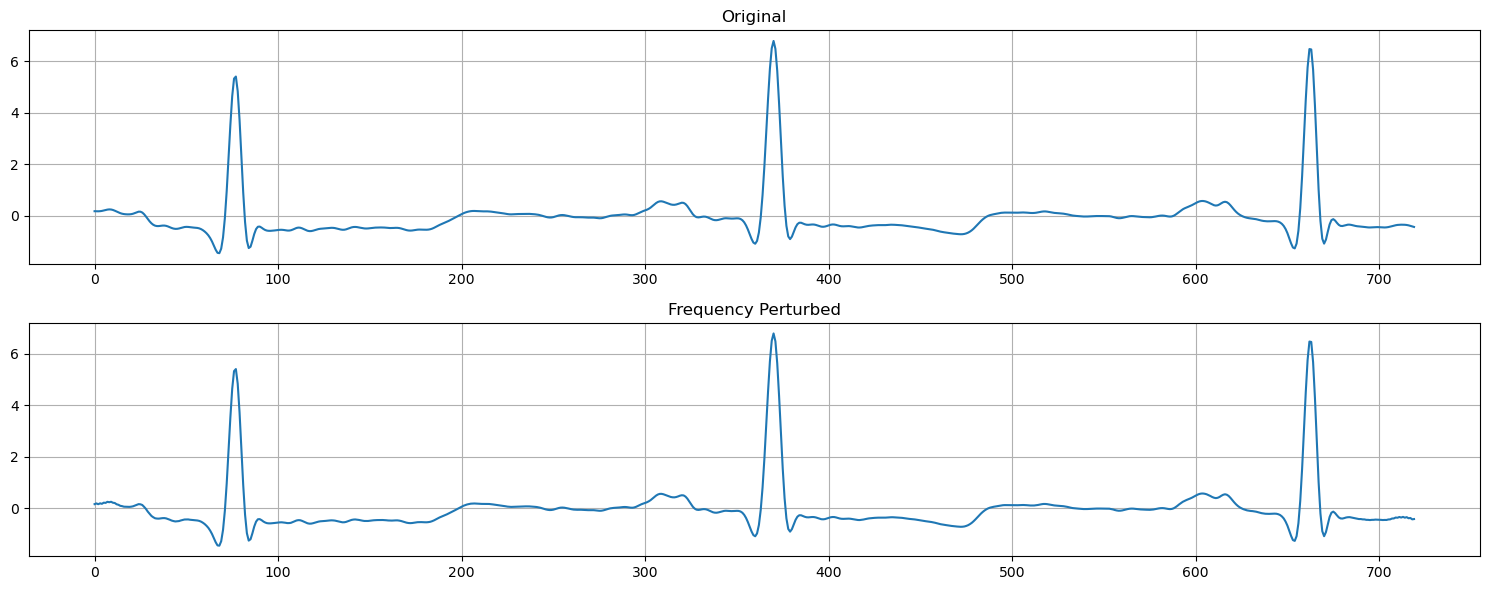

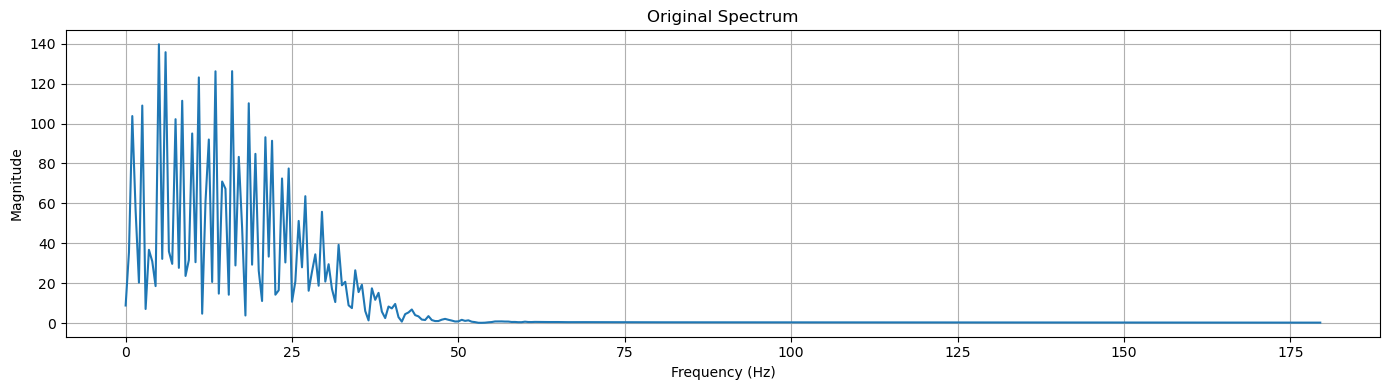

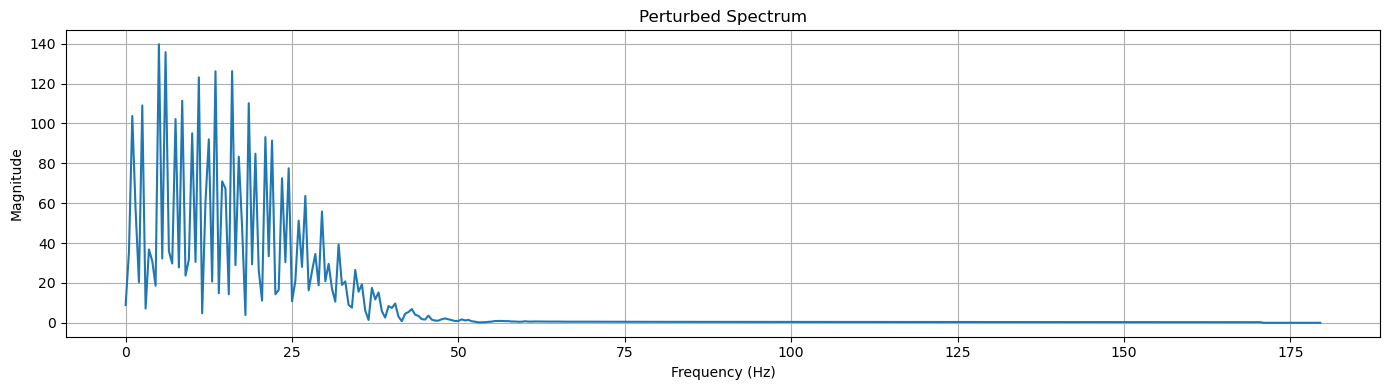

  morphology_sharpening  gamma=2.0, lambda=0.5


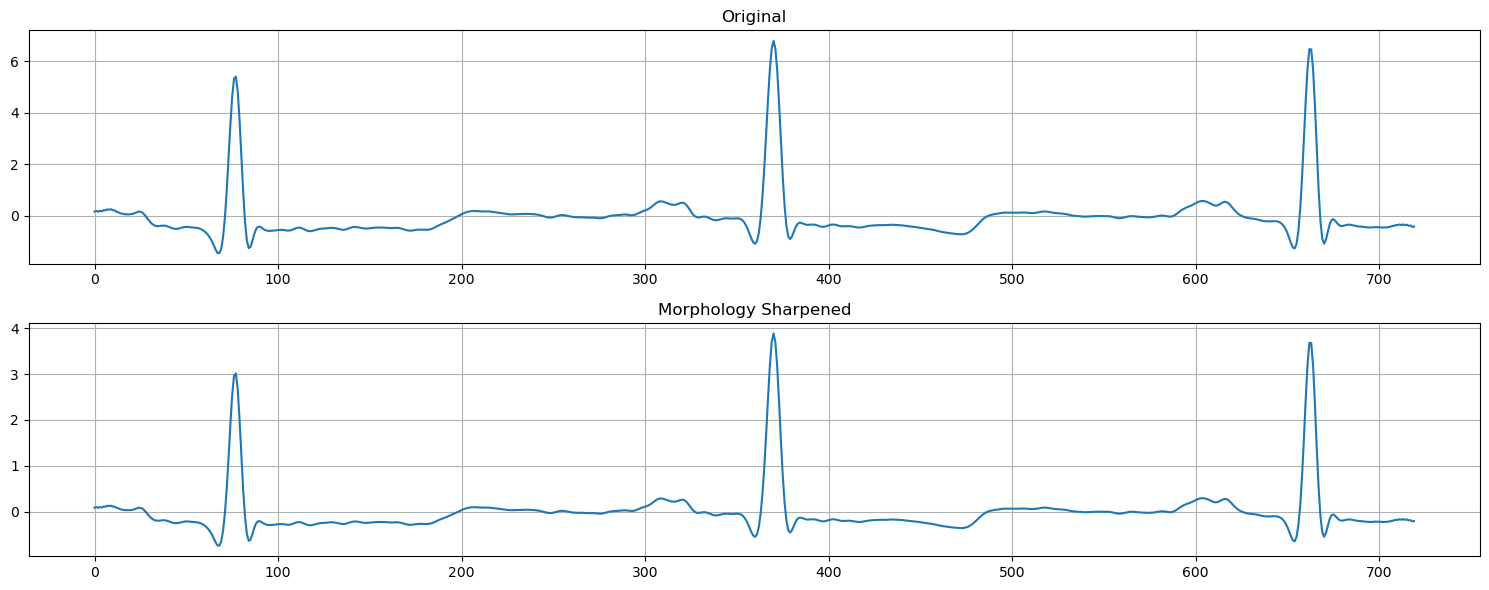

  rhythm_variation  noise_level=0.15


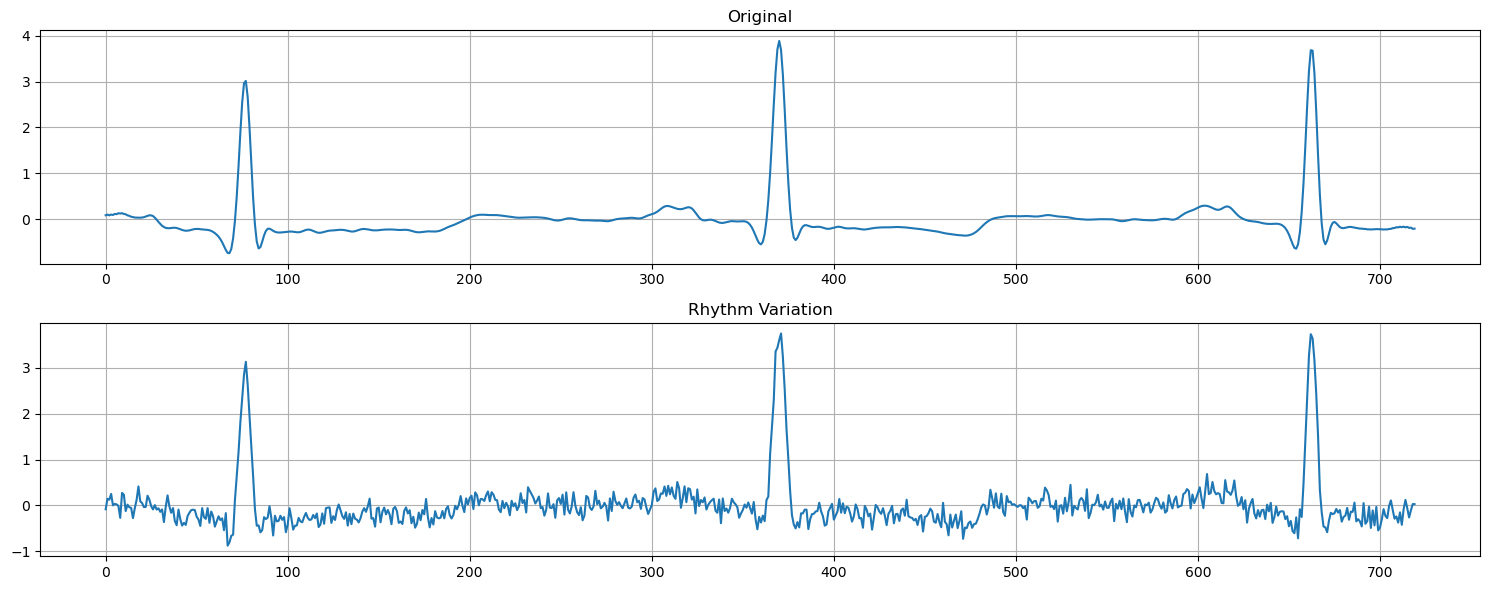

In [39]:
sample = normal_windows[0]
print("Generating one synthetic anomaly with visualisation ...")
_ = generate_negative_sample(sample, visualize=True)

## 13 — Build Datasets & DataLoaders

In [40]:
train_dataset       = ECGDataset(train_windows)        # normal + on-the-fly synthetic anomalies
val_monitor_dataset = ECGDataset(val_windows)          # FIX 2: mixed — used to compute val F1
val_threshold_dataset = ValDataset(val_windows)        # normal-only — used for μ+k·σ threshold
test_dataset        = TestDataset(test_windows_final,  # FIX 1: annotation-based labels
                                  test_labels_final)

train_loader         = DataLoader(train_dataset,         batch_size=32, shuffle=True)
val_monitor_loader   = DataLoader(val_monitor_dataset,   batch_size=32, shuffle=False)
val_threshold_loader = DataLoader(val_threshold_dataset, batch_size=32, shuffle=False)
test_loader          = DataLoader(test_dataset,          batch_size=32, shuffle=False)

print(f"Train dataset:   {len(train_dataset):>5} samples (50 % normal / 50 % synthetic)")
print(f"Val monitor:     {len(val_monitor_dataset):>5} samples (mixed — checkpoint metric)")
print(f"Val threshold:   {len(val_threshold_dataset):>5} samples (normal-only — μ+k·σ)")
print(f"Test dataset:    {len(test_dataset):>5} samples (real annotation labels)")

Train dataset:   17678 samples (50 % normal / 50 % synthetic)
Val monitor:      3788 samples (mixed — checkpoint metric)
Val threshold:    1894 samples (normal-only — μ+k·σ)
Test dataset:     5503 samples (real annotation labels)


## 14 — Initialise Model

In [41]:
model = ECGFRCNN(
    lstm_hidden   = 64,
    cnn_filters_1 = 64,
    cnn_filters_2 = 128,
    kernel_size   = 5,
    dropout       = 0.3,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

ECGFRCNN(
  (lstm): LSTM(1, 64, batch_first=True)
  (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (gap): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 79,297


## 15 — Train

In [42]:
model, train_losses, val_f1_scores = run_training(
    model,
    train_loader,
    val_monitor_loader,
    num_epochs       = 10,
    checkpoint_path  = "best_ecg_model.pt",
)


Starting training ...

 Epoch  Train Loss    Val F1        LR
---------------------------------------------
  01/10  loss=0.3726  val_f1=0.0494  lr=0.00100  ← saved
  02/10  loss=0.2969  val_f1=0.8893  lr=0.00100  ← saved
  03/10  loss=0.2731  val_f1=0.9188  lr=0.00050  ← saved
  04/10  loss=0.2501  val_f1=0.9146  lr=0.00050
  05/10  loss=0.2315  val_f1=0.9215  lr=0.00050  ← saved
  06/10  loss=0.2385  val_f1=0.9160  lr=0.00025
  07/10  loss=0.2207  val_f1=0.9182  lr=0.00025
  08/10  loss=0.2227  val_f1=0.9231  lr=0.00025  ← saved
  09/10  loss=0.2209  val_f1=0.9206  lr=0.00013
  10/10  loss=0.2184  val_f1=0.9249  lr=0.00013  ← saved

Best val F1: 0.9249
Best checkpoint loaded.


## 16 — Training Curves

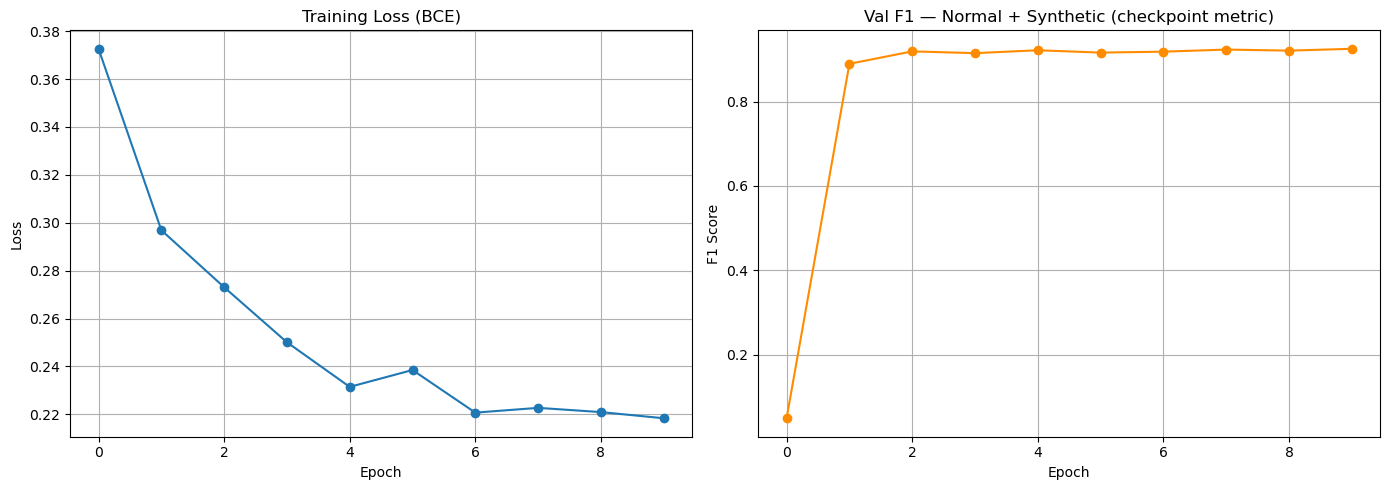

In [43]:
plot_training_curves(train_losses, val_f1_scores)

## 17 — Threshold Estimation 

In [ ]:
@torch.no_grad()
def find_best_threshold(model, val_monitor_loader, device):
    model.eval()
    all_probs, all_labels = [], []

    for signals, labels in val_monitor_loader:
        probs = torch.sigmoid(model(signals.to(device))).cpu().numpy().reshape(-1)
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.numpy().tolist())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    best_f1, best_thresh = 0.0, 0.5
    for t in np.linspace(0.05, 0.95, 200):
        preds = (all_probs > t).astype(int)
        score = f1_score(all_labels, preds, zero_division=0)
        if score > best_f1:
            best_f1, best_thresh = score, t

    print(f"Optimal threshold: {best_thresh:.3f}  (val F1 = {best_f1:.4f})")
    return best_thresh


threshold = find_best_threshold(model, val_monitor_loader, device)

Optimal threshold: 0.633  (val F1 = 0.9157)


## 18 — Evaluation on Real Arrhythmia Test Set

Evaluating on annotation-labelled test set ...

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.59      0.74      4050
     Anomaly       0.46      0.97      0.63      1453

    accuracy                           0.69      5503
   macro avg       0.72      0.78      0.68      5503
weighted avg       0.85      0.69      0.71      5503



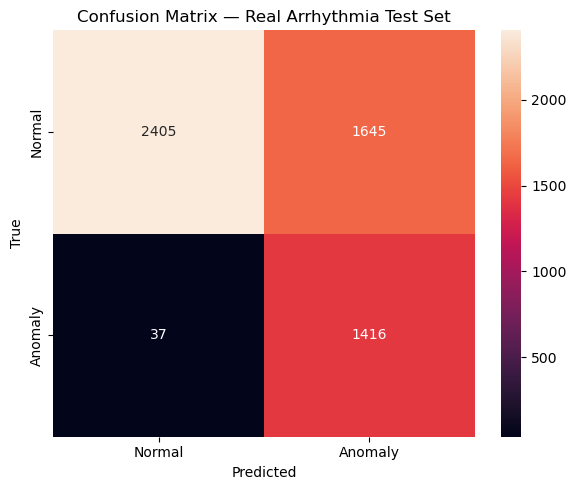

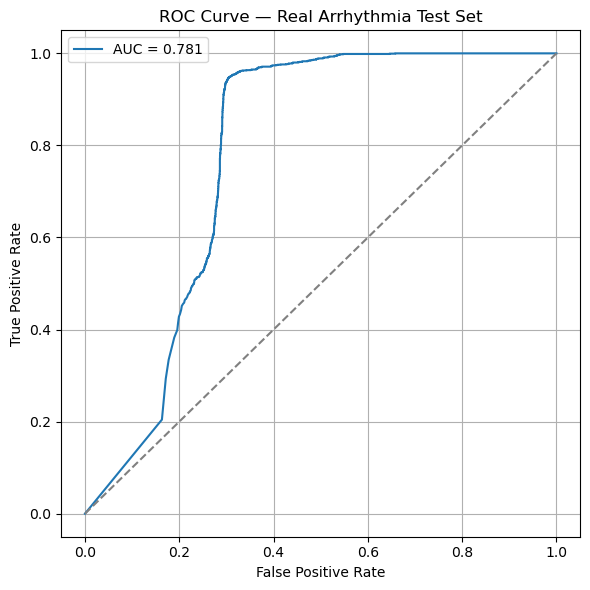

In [45]:
print("Evaluating on annotation-labelled test set ...")
full_evaluation(model, test_loader, threshold)

## 19 — Prediction Visualisation

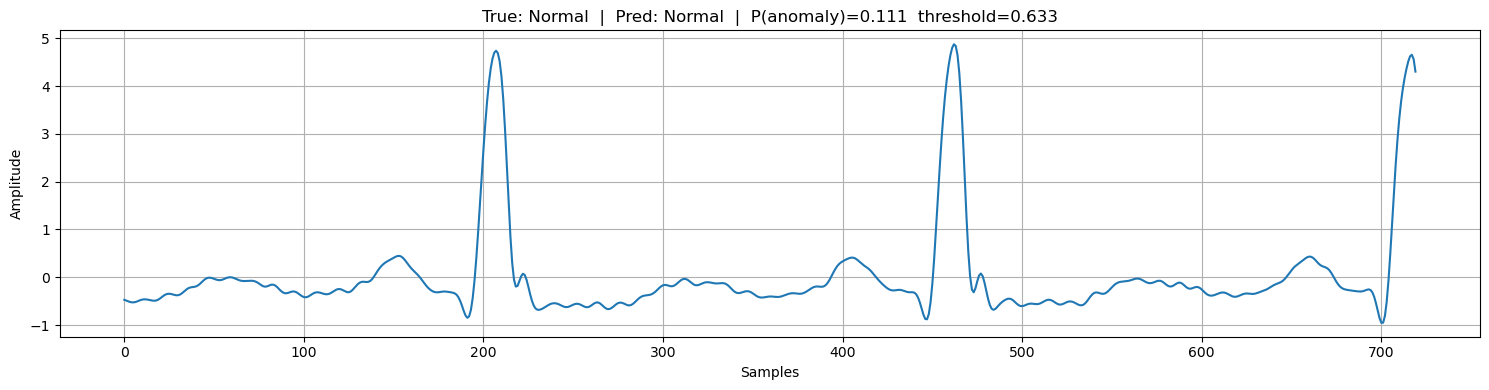

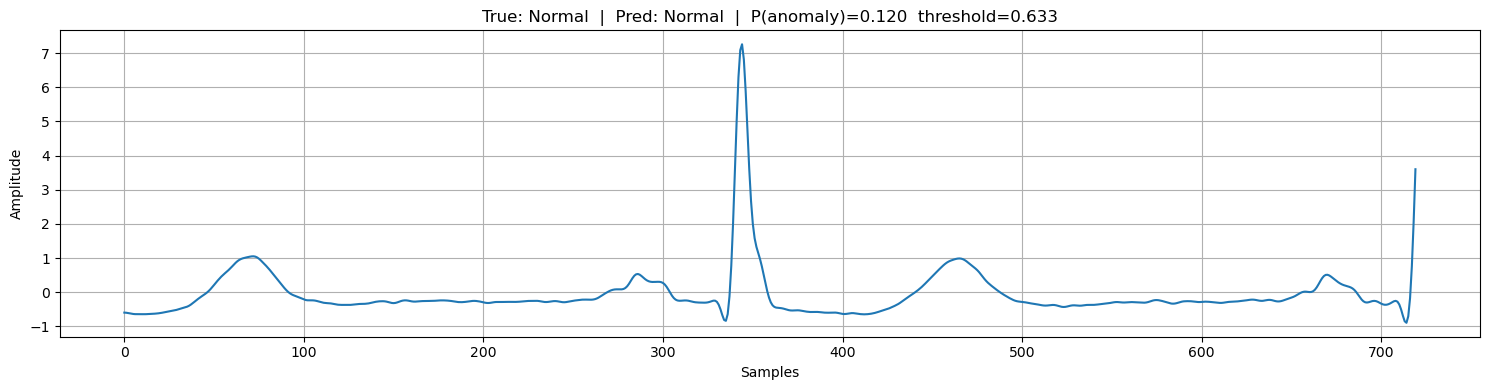

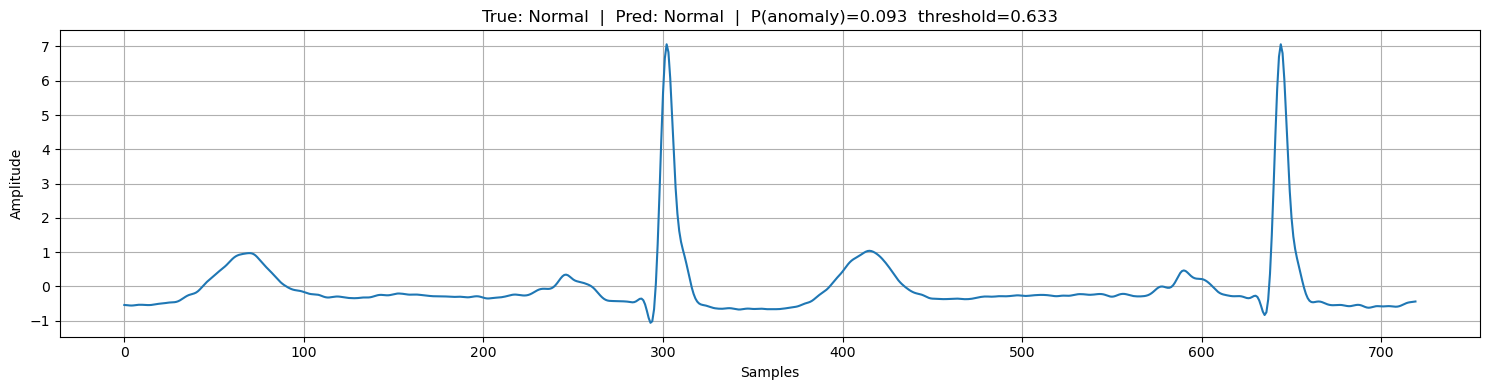

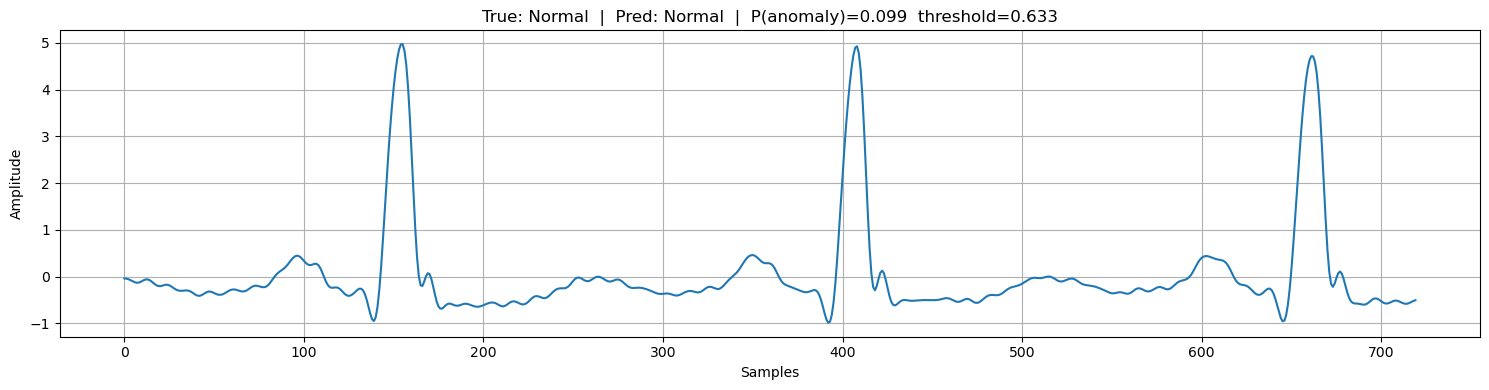

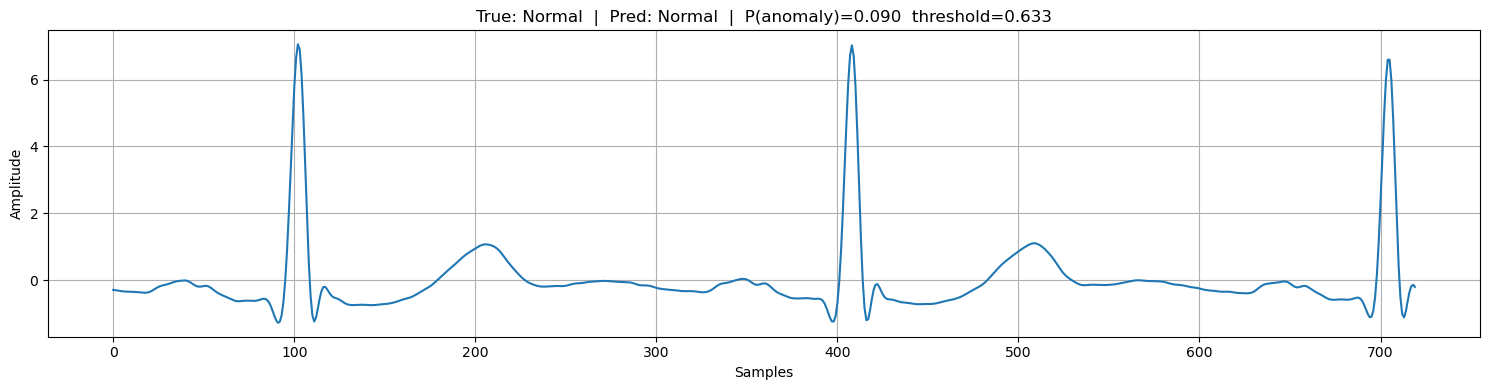

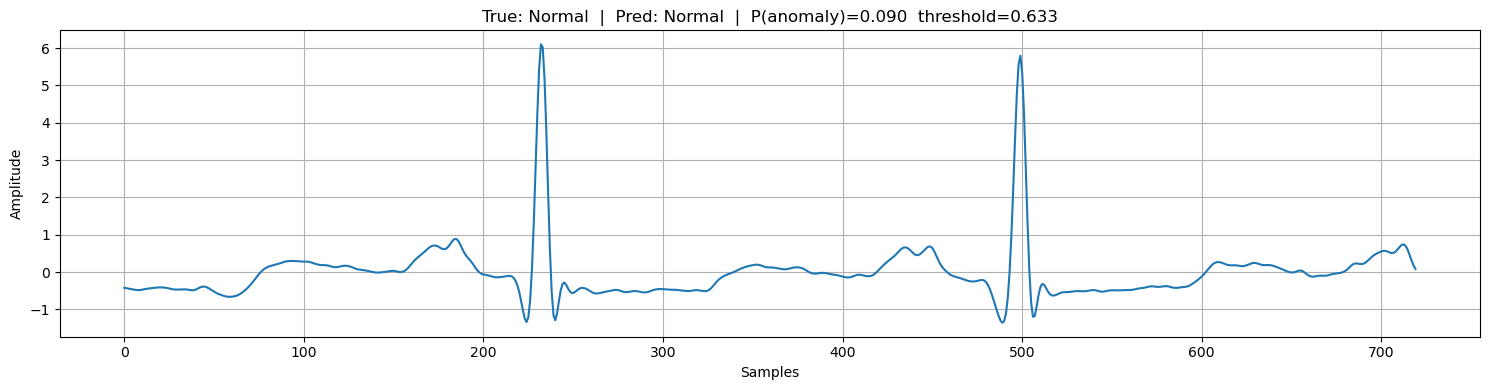

In [46]:
visualize_predictions(model, test_dataset, threshold, num_samples=6)

=== VAL MONITOR (record 100 — what threshold was tuned on) ===
  Normal scores   μ=0.118  σ=0.065  max=0.998
  Synth anomaly   μ=0.883  σ=0.295  min=0.073

=== TEST SET (records 108 & 200 — what it actually runs on) ===
  Normal scores   μ=0.498  σ=0.399  max=1.000
  Anomaly scores  μ=0.980  σ=0.102  min=0.120


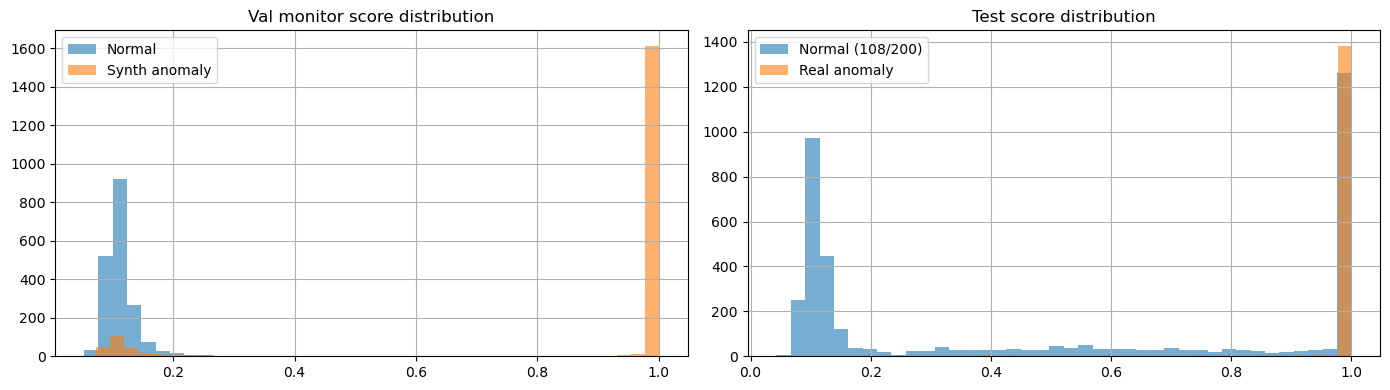

In [47]:
# ── DIAGNOSTIC — run this before re-training ────────────────────────────
@torch.no_grad()
def score_diagnostic(model, test_loader, val_monitor_loader, device):
    model.eval()

    def get_scores(loader):
        scores, labels = [], []
        for signals, lbls in loader:
            p = torch.sigmoid(model(signals.to(device))).cpu().numpy().reshape(-1)
            scores.extend(p.tolist())
            labels.extend(lbls.numpy().tolist())
        return np.array(scores), np.array(labels)

    test_scores,  test_labels  = get_scores(test_loader)
    val_scores,   val_labels   = get_scores(val_monitor_loader)

    print("=== VAL MONITOR (record 100 — what threshold was tuned on) ===")
    print(f"  Normal scores   μ={val_scores[val_labels==0].mean():.3f}  "
          f"σ={val_scores[val_labels==0].std():.3f}  "
          f"max={val_scores[val_labels==0].max():.3f}")
    print(f"  Synth anomaly   μ={val_scores[val_labels==1].mean():.3f}  "
          f"σ={val_scores[val_labels==1].std():.3f}  "
          f"min={val_scores[val_labels==1].min():.3f}")

    print("\n=== TEST SET (records 108 & 200 — what it actually runs on) ===")
    print(f"  Normal scores   μ={test_scores[test_labels==0].mean():.3f}  "
          f"σ={test_scores[test_labels==0].std():.3f}  "
          f"max={test_scores[test_labels==0].max():.3f}")
    print(f"  Anomaly scores  μ={test_scores[test_labels==1].mean():.3f}  "
          f"σ={test_scores[test_labels==1].std():.3f}  "
          f"min={test_scores[test_labels==1].min():.3f}")

    # Score distribution plot
    plt.figure(figsize=(14, 4))
    plt.subplot(1, 2, 1)
    plt.hist(val_scores[val_labels==0],  bins=40, alpha=0.6, label="Normal")
    plt.hist(val_scores[val_labels==1],  bins=40, alpha=0.6, label="Synth anomaly")
    plt.title("Val monitor score distribution"); plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.hist(test_scores[test_labels==0], bins=40, alpha=0.6, label="Normal (108/200)")
    plt.hist(test_scores[test_labels==1], bins=40, alpha=0.6, label="Real anomaly")
    plt.title("Test score distribution"); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

score_diagnostic(model, test_loader, val_monitor_loader, device)

Searching dataset for all 4 combinations...


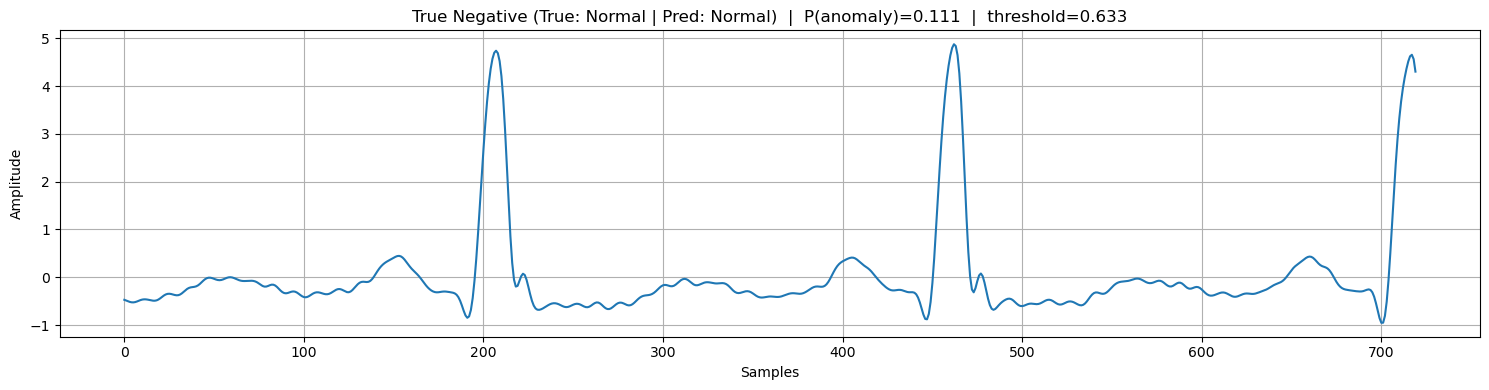

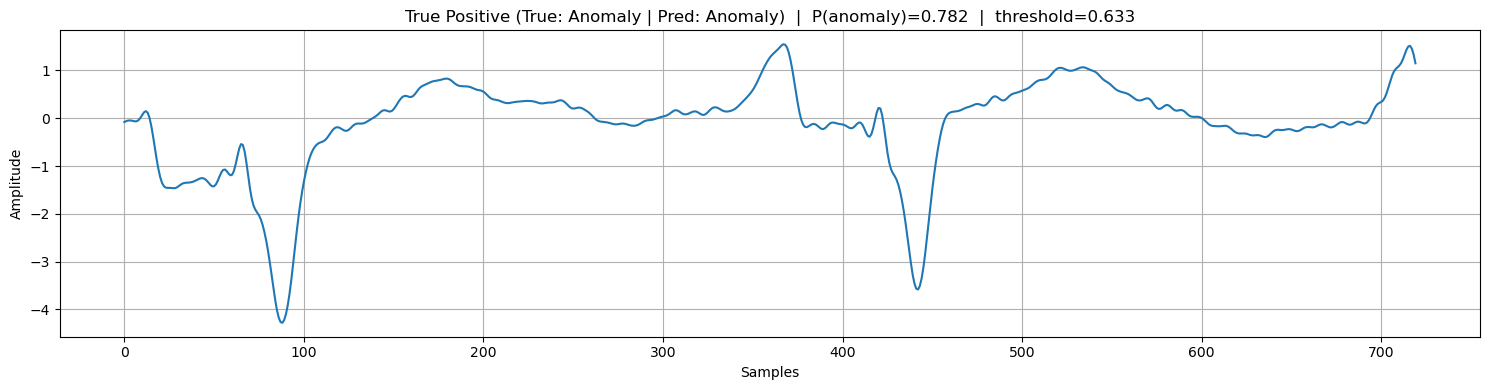

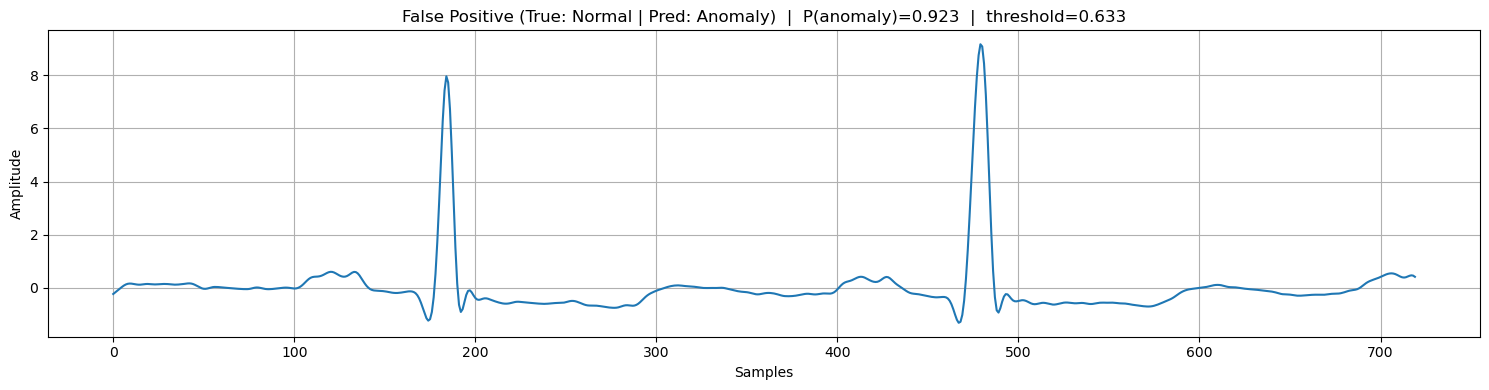

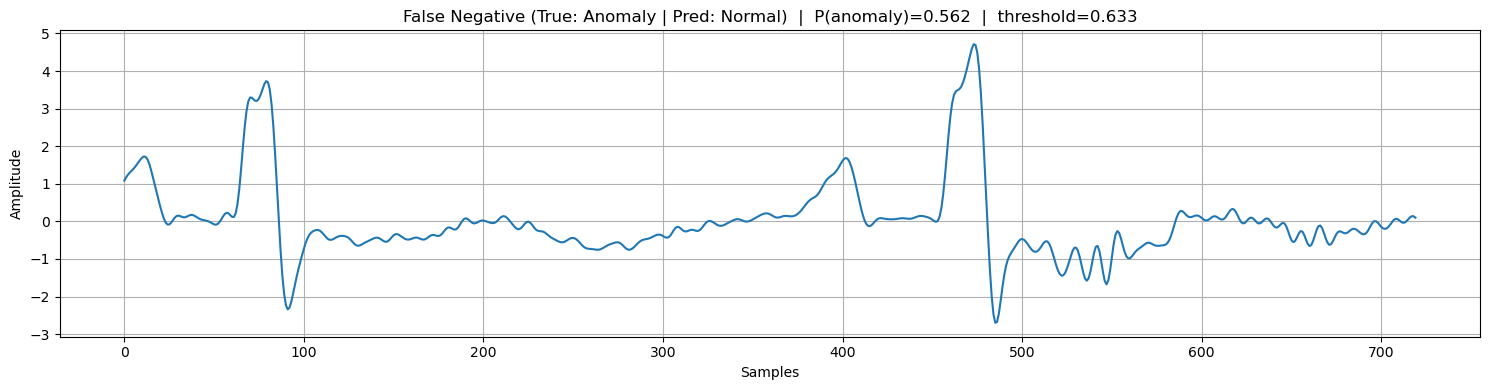

In [49]:
import torch

@torch.no_grad()
def plot_all_prediction_combinations(model, dataset, threshold_val: float):
    model.eval()
    
    # A dictionary to store the first example we find for each of the 4 quadrants
    examples = {
        "True Negative (True: Normal | Pred: Normal)": None,
        "True Positive (True: Anomaly | Pred: Anomaly)": None,
        "False Positive (True: Normal | Pred: Anomaly)": None,    # False Alarm
        "False Negative (True: Anomaly | Pred: Normal)": None     # Missed Anomaly
    }
    
    print("Searching dataset for all 4 combinations...")
    
    for i in range(len(dataset)):
        signal, label = dataset[i]
        
        # Get the model's prediction probability. 
        # Using the 'device' variable already defined in your notebook.
        prob = torch.sigmoid(model(signal.unsqueeze(0).to(device))).item()
        pred = int(prob > threshold_val)
        
        # Format the true label
        true_label = int(label.item() if isinstance(label, torch.Tensor) else label)
        
        # 1. True Negative
        if true_label == 0 and pred == 0 and examples["True Negative (True: Normal | Pred: Normal)"] is None:
            examples["True Negative (True: Normal | Pred: Normal)"] = (signal, prob)
            
        # 2. True Positive
        elif true_label == 1 and pred == 1 and examples["True Positive (True: Anomaly | Pred: Anomaly)"] is None:
            examples["True Positive (True: Anomaly | Pred: Anomaly)"] = (signal, prob)
            
        # 3. False Positive (False Alarm)
        elif true_label == 0 and pred == 1 and examples["False Positive (True: Normal | Pred: Anomaly)"] is None:
            examples["False Positive (True: Normal | Pred: Anomaly)"] = (signal, prob)
            
        # 4. False Negative (Missed Anomaly)
        elif true_label == 1 and pred == 0 and examples["False Negative (True: Anomaly | Pred: Normal)"] is None:
            examples["False Negative (True: Anomaly | Pred: Normal)"] = (signal, prob)
            
        # Stop searching if we have found all 4 combinations!
        if all(v is not None for v in examples.values()):
            break
            
    # Plot the results
    for title, data in examples.items():
        if data is not None:
            signal, prob = data
            # using plot_ecg from your notebook
            plot_ecg(
                signal.squeeze().numpy(), 
                title=f"{title}  |  P(anomaly)={prob:.3f}  |  threshold={threshold_val:.3f}"
            )
        else:
            print(f"⚠️ Could not find an example for: {title}")
            print("  (Your model might be too accurate on this test set to make this specific mistake!)")

# --- RUN THE FUNCTION ---
# Using the exact variable 'threshold' defined in your notebook
plot_all_prediction_combinations(model, test_dataset, threshold)

Extracting real patient data from the test set...


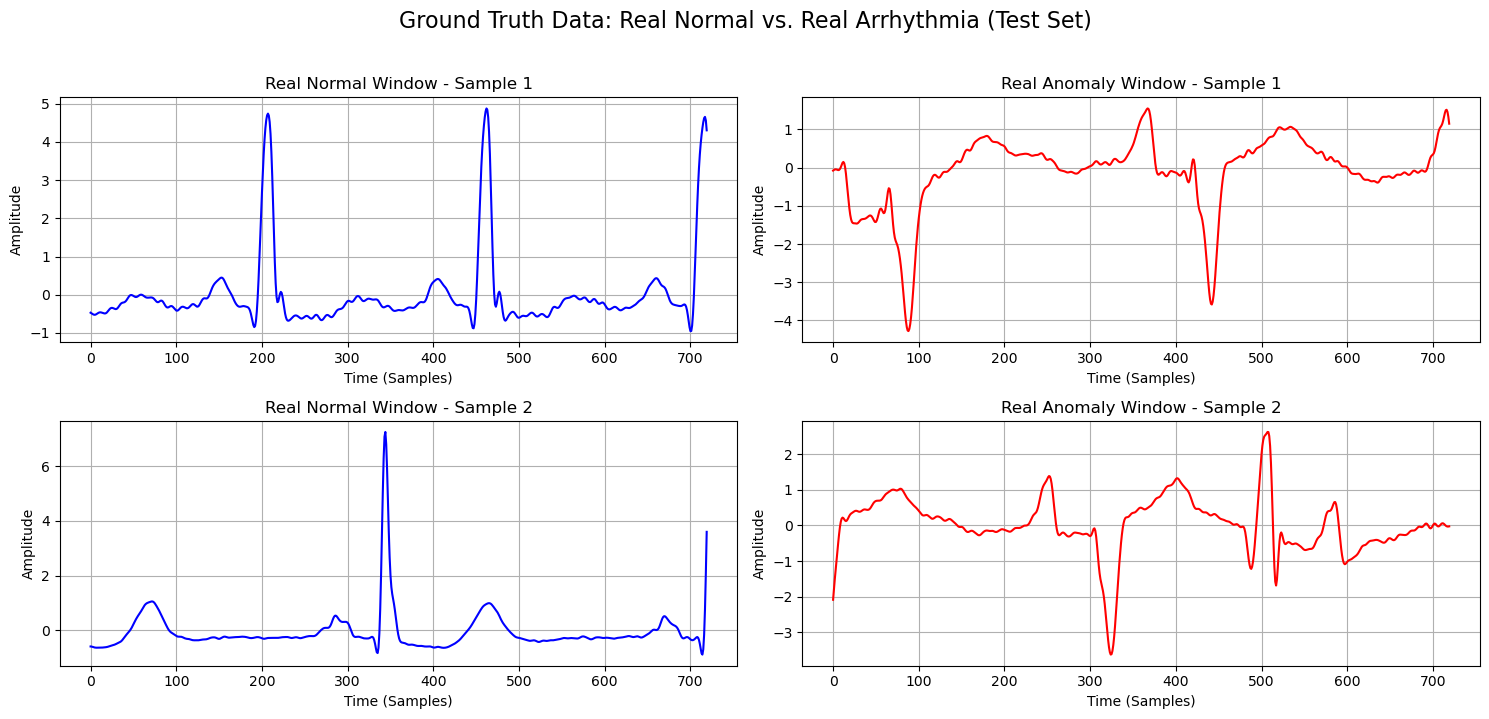

In [50]:
import matplotlib.pyplot as plt
import numpy as np

def plot_real_samples_for_slides(dataset, num_samples_per_class=2):
    normals = []
    anomalies = []
    
    print("Extracting real patient data from the test set...")
    
    # Hunt through the dataset for ground truth labels
    for i in range(len(dataset)):
        signal, label = dataset[i]
        
        # Extract actual integer label (0 = Normal, 1 = Anomaly)
        true_label = int(label.item() if hasattr(label, 'item') else label)
        
        # Format the signal for plotting
        sig_np = signal.squeeze().numpy() if hasattr(signal, 'numpy') else np.array(signal).squeeze()
        
        # Collect normals
        if true_label == 0 and len(normals) < num_samples_per_class:
            normals.append(sig_np)
        # Collect anomalies
        elif true_label == 1 and len(anomalies) < num_samples_per_class:
            anomalies.append(sig_np)
            
        # Stop if we have enough of both
        if len(normals) == num_samples_per_class and len(anomalies) == num_samples_per_class:
            break
            
    # --- Plotting the Grid for Slides ---
    fig, axes = plt.subplots(num_samples_per_class, 2, figsize=(15, 3.5 * num_samples_per_class))
    fig.suptitle("Ground Truth Data: Real Normal vs. Real Arrhythmia (Test Set)", fontsize=16, y=1.02)
    
    for i in range(num_samples_per_class):
        # Plot Normal (Left Column)
        if i < len(normals):
            axes[i, 0].plot(normals[i], color='blue', linewidth=1.5)
            axes[i, 0].set_title(f"Real Normal Window - Sample {i+1}", fontsize=12)
            axes[i, 0].set_xlabel("Time (Samples)")
            axes[i, 0].set_ylabel("Amplitude")
            axes[i, 0].grid(True)
        
        # Plot Anomaly (Right Column)
        if i < len(anomalies):
            axes[i, 1].plot(anomalies[i], color='red', linewidth=1.5)
            axes[i, 1].set_title(f"Real Anomaly Window - Sample {i+1}", fontsize=12)
            axes[i, 1].set_xlabel("Time (Samples)")
            axes[i, 1].set_ylabel("Amplitude")
            axes[i, 1].grid(True)
            
    plt.tight_layout()
    plt.show()

# --- RUN THE FUNCTION ---
# This uses the test_dataset which contains the real annotated patient data
plot_real_samples_for_slides(test_dataset, num_samples_per_class=2)

Generating synthetic anomalies...


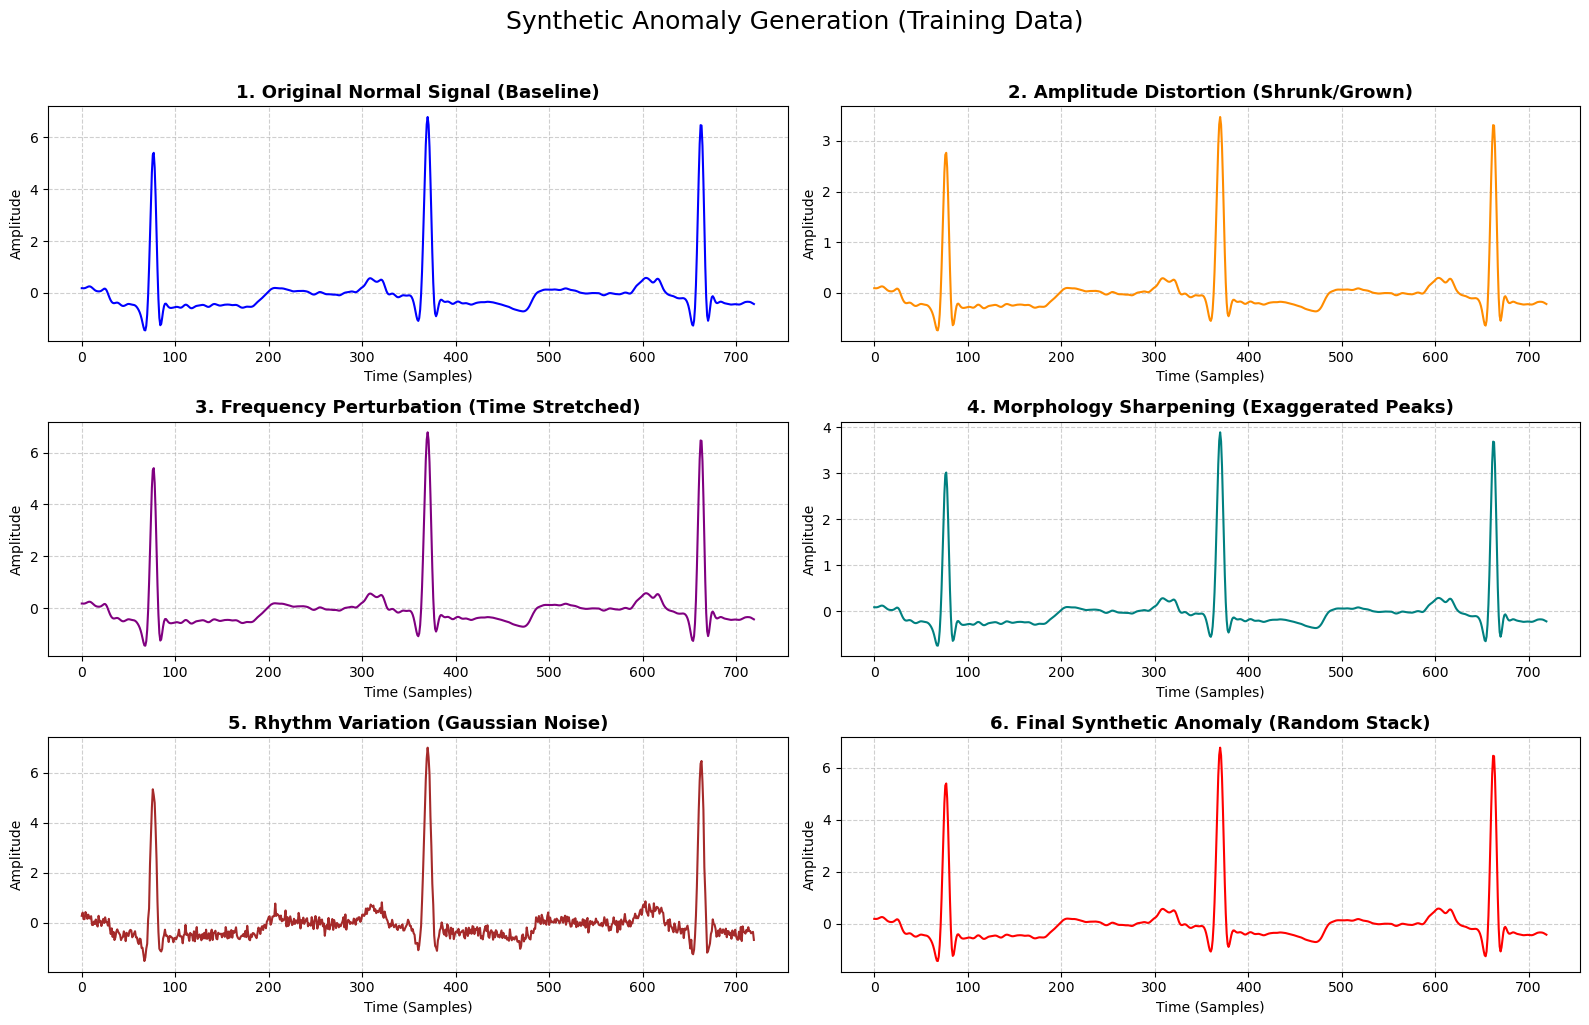

In [51]:
import matplotlib.pyplot as plt
import numpy as np

def plot_synthetic_augmentations_for_slides(normal_windows):
    # Grab one clean, normal window to use as our baseline
    base_signal = normal_windows[0]
    
    print("Generating synthetic anomalies...")
    
    # Generate the synthetic variations using your notebook's functions
    # (Setting a seed so the random generation looks good for the presentation)
    np.random.seed(42) 
    
    amp_dist = amplitude_distortion(base_signal)
    freq_pert = frequency_perturbation(base_signal)
    morph_sharp = morphology_sharpening(base_signal)
    rhythm_var = rhythm_variation(base_signal)
    
    # Generate a fully stacked negative sample (what the model actually trains on)
    stacked_anomaly = generate_negative_sample(base_signal)
    
    # --- Plotting the Grid for Slides ---
    fig, axes = plt.subplots(3, 2, figsize=(16, 10))
    fig.suptitle("Synthetic Anomaly Generation (Training Data)", fontsize=18, y=1.02)
    
    # Helper to format plots
    def format_plot(ax, signal, title, color):
        ax.plot(signal, color=color, linewidth=1.5)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel("Time (Samples)")
        ax.set_ylabel("Amplitude")
        ax.grid(True, linestyle='--', alpha=0.6)

    # 1. Original (Top Left)
    format_plot(axes[0, 0], base_signal, "1. Original Normal Signal (Baseline)", 'blue')
    
    # 2. Amplitude Distortion (Top Right)
    format_plot(axes[0, 1], amp_dist, "2. Amplitude Distortion (Shrunk/Grown)", 'darkorange')
    
    # 3. Frequency Perturbation (Middle Left)
    format_plot(axes[1, 0], freq_pert, "3. Frequency Perturbation (Time Stretched)", 'purple')
    
    # 4. Morphology Sharpening (Middle Right)
    format_plot(axes[1, 1], morph_sharp, "4. Morphology Sharpening (Exaggerated Peaks)", 'teal')
    
    # 5. Rhythm Variation (Bottom Left)
    format_plot(axes[2, 0], rhythm_var, "5. Rhythm Variation (Gaussian Noise)", 'brown')
    
    # 6. Final Stacked Sample (Bottom Right)
    format_plot(axes[2, 1], stacked_anomaly, "6. Final Synthetic Anomaly (Random Stack)", 'red')
    
    plt.tight_layout()
    plt.show()

# --- RUN THE FUNCTION ---
# This uses the normal_windows array already loaded in your notebook
plot_synthetic_augmentations_for_slides(normal_windows)

In [52]:
!pip install torchinfo



In [53]:


from torchinfo import summary

# Pass your model and the shape of a single input batch
# Batch size = 32, Channels = 1, Sequence Length = 720
summary(model, input_size=(32, 1, 720))

Layer (type:depth-idx)                   Output Shape              Param #
ECGFRCNN                                 [32]                      --
├─LSTM: 1-1                              [32, 720, 64]             17,152
├─Conv1d: 1-2                            [32, 64, 720]             20,544
├─BatchNorm1d: 1-3                       [32, 64, 720]             128
├─ReLU: 1-4                              [32, 64, 720]             --
├─MaxPool1d: 1-5                         [32, 64, 360]             --
├─Conv1d: 1-6                            [32, 128, 360]            41,088
├─BatchNorm1d: 1-7                       [32, 128, 360]            256
├─ReLU: 1-8                              [32, 128, 360]            --
├─MaxPool1d: 1-9                         [32, 128, 180]            --
├─AdaptiveAvgPool1d: 1-10                [32, 128, 1]              --
├─Dropout: 1-11                          [32, 128]                 --
├─Linear: 1-12                           [32, 1]                   129
